# Customer Churn — Predictive Modelling

## Objective

The objective of this project is to develop a predictive machine learning model using customer churn data to identify customers who are likely to churn. The project demonstrates the application of machine learning techniques for customer churn prediction.

## Dataset

The Churn 80 dataset is used to train and evaluate a predictive model for identifying potential customer churn.

## Technologies Used

* Python
* Pandas
* NumPy
* Matplotlib
* Seaborn
* Scikit-learn
* Jupyter Notebook

## Workflow

1. Load and inspect the customer churn dataset
2. Perform data preprocessing and prepare the features
3. Select the target variable for churn prediction
4. Split the dataset into training and testing sets
5. Train a suitable machine learning classification model
6. Generate predictions using the test data
7. Evaluate model performance using appropriate metrics
8. Visualize and interpret the model results
9. Summarize the key findings

## Conclusion

A predictive machine learning model was developed using the Churn 80 dataset to predict customer churn. The model was evaluated using appropriate performance metrics, providing insights into its ability to identify customers who may be likely to churn.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving churn-bigml-80.csv to churn-bigml-80.csv


In [ ]:
import pandas as pd

df = pd.read_csv("churn-bigml-80.csv")

df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [ ]:
print(df.columns.tolist())

['State', 'Account length', 'Area code', 'International plan', 'Voice mail plan', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls', 'Churn']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

In [ ]:
df.isnull().sum()

,0
State,0
Account length,0
Area code,0
International plan,0
Voice mail plan,0
Number vmail messages,0
Total day minutes,0
Total day calls,0
Total day charge,0
Total eve minutes,0


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
df["Churn"].value_counts()

,count
Churn,
False,2278
True,388


In [ ]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
False,85.446362
True,14.553638


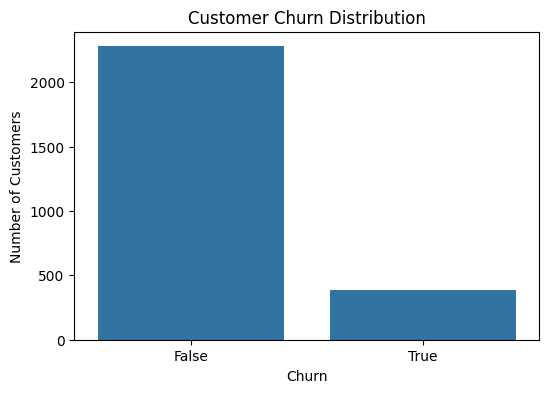

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

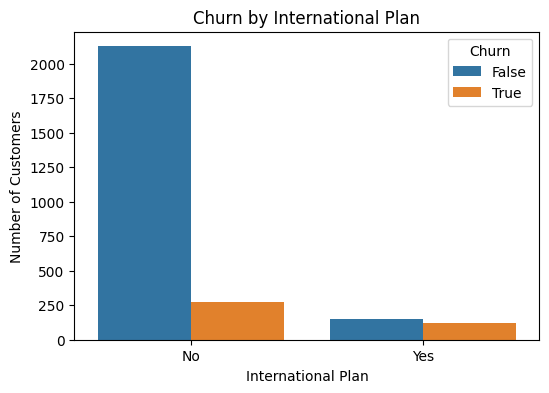

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(x="International plan", hue="Churn", data=df)

plt.title("Churn by International Plan")
plt.xlabel("International Plan")
plt.ylabel("Number of Customers")

plt.show()

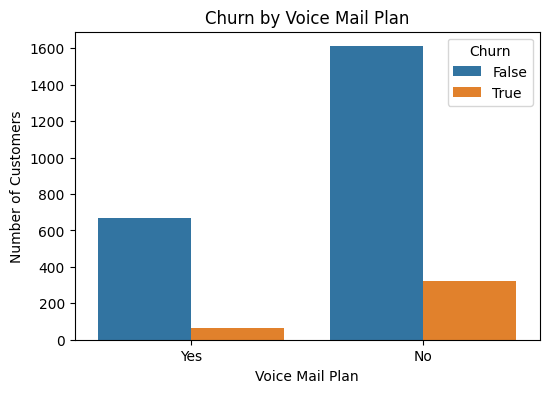

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(x="Voice mail plan", hue="Churn", data=df)

plt.title("Churn by Voice Mail Plan")
plt.xlabel("Voice Mail Plan")
plt.ylabel("Number of Customers")

plt.show()

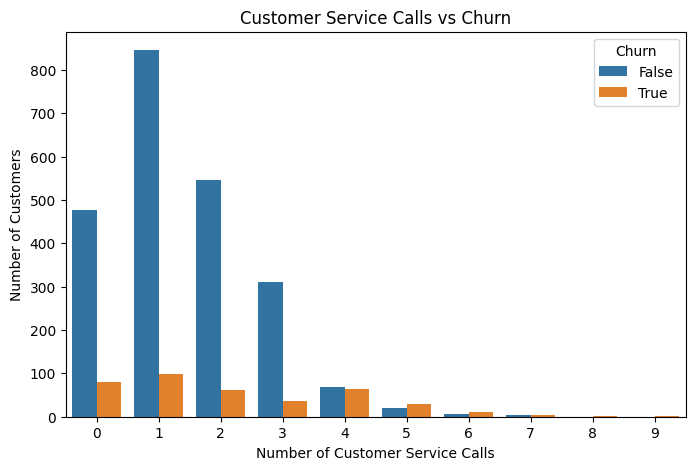

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(x="Customer service calls", hue="Churn", data=df)

plt.title("Customer Service Calls vs Churn")
plt.xlabel("Number of Customer Service Calls")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
df["Churn_numeric"] = df["Churn"].astype(int)

print(df[["Churn", "Churn_numeric"]].head())

   Churn  Churn_numeric
0  False              0
1  False              0
2  False              0
3  False              0
4  False              0


In [ ]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

correlation = numeric_df.corr()

print(correlation["Churn_numeric"].sort_values(ascending=False))

Churn_numeric             1.000000
Customer service calls    0.202590
Total day charge          0.195689
Total day minutes         0.195688
Total intl charge         0.086216
Total intl minutes        0.086204
Total eve minutes         0.072906
Total eve charge          0.072893
Total night minutes       0.033639
Total night charge        0.033635
Total day calls           0.018290
Account length            0.017728
Total night calls         0.012262
Area code                 0.001019
Total eve calls          -0.001539
Total intl calls         -0.069882
Number vmail messages    -0.086474
Name: Churn_numeric, dtype: float64


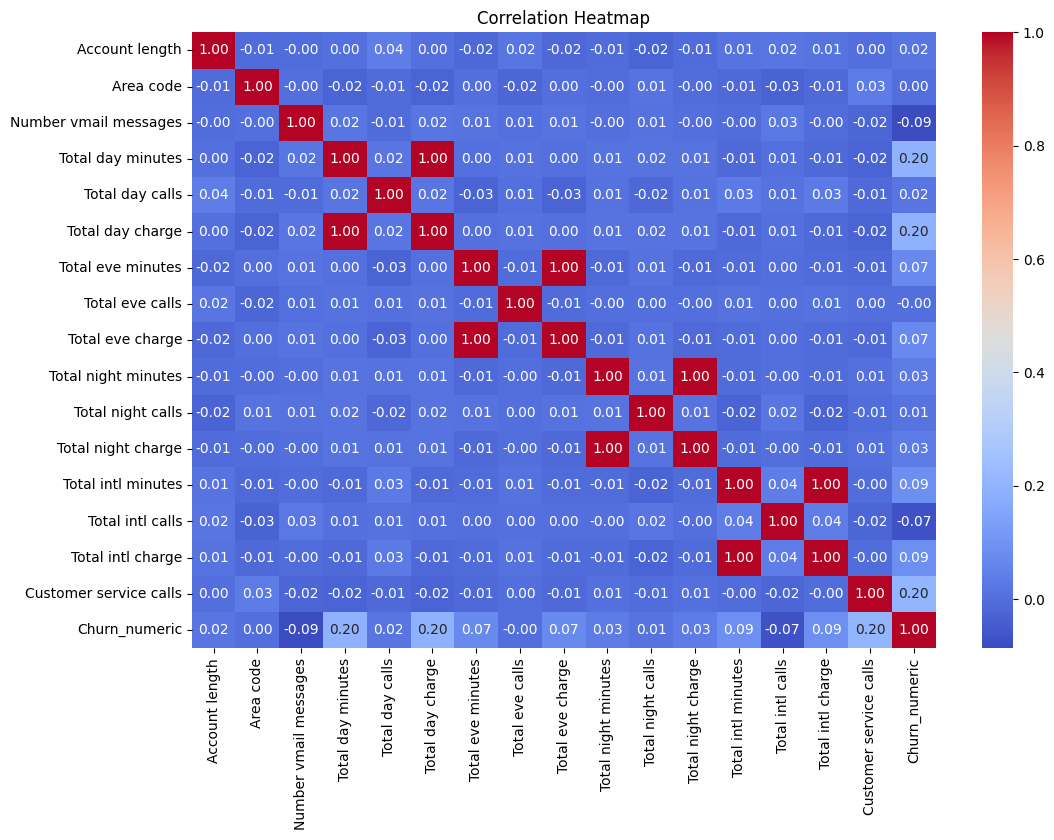

In [ ]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
churn_rate = df.groupby("Customer service calls")["Churn_numeric"].mean() * 100

print(churn_rate)

Customer service calls
0     14.234234
1     10.476190
2     10.197368
3     10.632184
4     48.120301
5     59.183673
6     58.823529
7     62.500000
8    100.000000
9    100.000000
Name: Churn_numeric, dtype: float64


In [ ]:
print(df.groupby("Churn")["Total day minutes"].describe())

        count        mean        std  min    25%     50%    75%    max
Churn                                                                 
False  2278.0  175.104346  50.105334  0.0  142.5  177.90  209.8  313.8
True    388.0  205.181186  68.490213  0.0  150.9  214.95  262.2  350.8


In [ ]:
print(df.columns.tolist())

['State', 'Account length', 'Area code', 'International plan', 'Voice mail plan', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls', 'Churn', 'Churn_numeric']


In [ ]:
model_df = df.copy()

y = model_df["Churn"].astype(int)

X = model_df.drop(columns=["Churn", "Churn_numeric"])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2666, 19)
y shape: (2666,)


In [ ]:
print(X.select_dtypes(include=["object"]).columns.tolist())

['State', 'International plan', 'Voice mail plan']


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "State",
    "International plan",
    "Voice mail plan"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [ ]:
print(preprocessor)

ColumnTransformer(remainder='passthrough',
                  transformers=[('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['State', 'International plan',
                                  'Voice mail plan'])])


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (2132, 19)
Testing data: (534, 19)
